# Charger le datraframe #

In [35]:
import pandas as pd
import unicodedata
df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)


# Supprime les espaces au début et à la fin des noms de colonnes #

In [36]:
df.columns = df.columns.str.strip()


# Supprimer les doublons #

In [37]:
df = df.drop_duplicates()
df[df.duplicated(keep=False)]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


# Supprimer les espaces en début de chaque valeur #

In [38]:
# Sélection des colonnes de type chaîne
string_cols = df.select_dtypes(include="object").columns

# Suppression des espaces en début et fin de chaque valeur
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())
# remplacer les espaces multiples par un seul
df[string_cols] = df[string_cols].apply(
    lambda col: col.str.replace(r"\s+", " ", regex=True).str.strip()
)
# vérifier que les espaces ont bien été supprimés
print(df.columns.tolist())

for col in string_cols:
    print(df[col].head())

C:\Users\yannb\AppData\Local\Temp\ipykernel_21676\3566595447.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include="object").columns


['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']
0    2024-03-23
1    2024-11-29
2    2024-08-23
3    2024-10-21
4    2024-09-16
Name: Date, dtype: str
0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: str
0    "CNR5884300"
1    "CNR1326809"
2    "CNR8494506"
3    "CNR8906825"
4    "CNR1950162"
Name: Booking ID, dtype: str
0    No Driver Found
1         Incomplete
2          Completed
3          Completed
4          Completed
Name: Booking Status, dtype: str
0    "CID1982111"
1    "CID4604802"
2    "CID9202816"
3    "CID2610914"
4    "CID9933542"
Name: Customer ID, dtype: str
0            eBike
1    

# Uniformiser les booking id #

In [39]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

# Uniformiser les dates #

In [40]:
import re
from datetime import datetime

def uniformiser_date(date):

    if not isinstance(date, str):
        return None

    date = date.strip()

    # Uniformiser les séparateurs
    date = re.sub(r"\s*-\s*", "-", date)
    date = re.sub(r"\s+", "-", date)
    date = date.replace("/", "-")

    formats = [
        "%Y-%m-%d",   # 1995-02-10
        "%m-%d-%Y",   # 09-21-1972
        "%d-%m-%Y",   # 23-07-2008
        "%d-%b-%y",   # 22-Feb-04
        "%d-%B-%Y",   # 22-February-2004
        "%d-%b-%Y",   # 22-Feb-2004
    ]

    for fmt in formats:
        try:
            d = datetime.strptime(date, fmt)
            return d.strftime("%Y/%m/%d")
        except ValueError:
            pass

    return None

df["Date"] = df["Date"].apply(uniformiser_date)

# Remplacer les pourcentages de données manquantes # 

In [41]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
}).sort_values("Percentage", ascending=False)
df.groupby("Booking Status")["Booking Value"].apply(lambda x: x.isna().sum())                     
df.groupby("Booking Status")["Ride Distance"].apply(lambda x: x.isna().sum())         
df.groupby("Booking Status")["Customer Rating"].apply(lambda x: x.isna().sum())  
text_cols = [
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]          # nettoyage des columns de texte  
df[text_cols].head(10)            
df[text_cols].isnull().sum()     
df[text_cols][df[text_cols].isnull().any(axis=1)].head(10)      
for col in text_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False)) 
    df[text_cols] = df[text_cols].fillna("Not Applicable")



Reason for cancelling by Customer
Reason for cancelling by Customer
NaN                                             139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64

Driver Cancellation Reason
Driver Cancellation Reason
Not Applicable                         123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

Incomplete Rides Reason
Incomplete Rides Reason
Not Applicable       141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64


# Nettoyage des colonnes numériques #

In [42]:
cols = [
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

# Vérification avant nettoyage
print("Avant nettoyage :")
print(df[cols].isna().sum())

# Remplacement des NaN par 0
df[cols] = df[cols].fillna(0)

# Vérification après nettoyage
print("\nAprès nettoyage :")
print(df[cols].isna().sum())
customer_cancel_rate = df["Cancelled Rides by Customer"].mean() * 100
print(df["Cancelled Rides by Customer"].value_counts(dropna=False))
print(customer_cancel_rate)
taux_annulation_client = (
    df["Booking Status"]
    .eq("Cancelled by Customer")
    .mean()
    * 100
)

print(f"Taux annulation client : {taux_annulation_client:.2f}%")

Avant nettoyage :
Cancelled Rides by Customer    139500
Cancelled Rides by Driver      123000
Incomplete Rides               141000
dtype: int64

Après nettoyage :
Cancelled Rides by Customer    0
Cancelled Rides by Driver      0
Incomplete Rides               0
dtype: int64
Cancelled Rides by Customer
0.0    139500
1.0     10500
Name: count, dtype: int64
7.000000000000001
Taux annulation client : 7.00%


In [43]:
df.isna().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

In [44]:
colonnes_nan = [
    "Booking Value",
    "Ride Distance",
    "Payment Method",
    "Driver Ratings",
    "Customer Rating"
]

for colonne in colonnes_nan:
    print("\n---", colonne, "---")
    print(
        df[df[colonne].isna()]["Booking Status"]
        .value_counts()
    )


--- Booking Value ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

--- Ride Distance ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

--- Payment Method ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

--- Driver Ratings ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

--- Customer Rating ---
Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


# Nettoyer les catégories #

In [45]:
for colonne in [
    "Vehicle Type",
    "Booking Status",
    "Payment Method",
    "Pickup Location",
    "Drop Location"
]:
    print(f"\n--- {colonne} ---")
    print(sorted(df[colonne].dropna().unique()))


--- Vehicle Type ---
['Auto', 'Bike', 'Go Mini', 'Go Sedan', 'Premier Sedan', 'Uber XL', 'eBike']

--- Booking Status ---
['Cancelled by Customer', 'Cancelled by Driver', 'Completed', 'Incomplete', 'No Driver Found']

--- Payment Method ---
['Cash', 'Credit Card', 'Debit Card', 'UPI', 'Uber Wallet']

--- Pickup Location ---
['AIIMS', 'Adarsh Nagar', 'Akshardham', 'Ambience Mall', 'Anand Vihar', 'Anand Vihar ISBT', 'Ardee City', 'Arjangarh', 'Ashok Park Main', 'Ashok Vihar', 'Ashram', 'Aya Nagar', 'Azadpur', 'Badarpur', 'Badshahpur', 'Bahadurgarh', 'Barakhamba Road', 'Basai Dhankot', 'Bhikaji Cama Place', 'Bhiwadi', 'Botanical Garden', 'Central Secretariat', 'Chanakyapuri', 'Chandni Chowk', 'Chhatarpur', 'Chirag Delhi', 'Civil Lines Gurgaon', 'Connaught Place', 'Cyber Hub', 'DLF City Court', 'DLF Phase 3', 'Delhi Gate', 'Dilshad Garden', 'Dwarka Mor', 'Dwarka Sector 21', 'Faridabad Sector 15', 'GTB Nagar', 'Ghaziabad', 'Ghitorni', 'Ghitorni Village', 'Golf Course Road', 'Govindpuri', '

# Vehicle Type #

In [46]:
vehicle_type_remplacement = {
    "Auto": "Auto",
    "Bike": "Bike",
    "eBike": "E-Bike",
    "Go Mini": "Mini",
    "Go Sedan": "Sedan",
    "Premier Sedan": "Premium Sedan",
    "Uber XL": "XL"
}

df["Vehicle Type"] = df["Vehicle Type"].replace(vehicle_type_remplacement)

# Booking Status #

In [47]:
booking_status_remplacement = {
    "Completed": "Success",
    "Cancelled by Customer": "Cancelled by Customer",
    "Cancelled by Driver": "Cancelled by Driver",
    "Incomplete": "Incomplete",
    "No Driver Found": "No Driver Found"
}

# Payment method #

In [48]:
payment_method_remplacement = {
    "Cash": "Cash",
    "Credit Card": "Card",
    "Debit Card": "Card",
    "UPI": "UPI",
    "Uber Wallet": "Wallet"
}

df["Payment Method"] = df["Payment Method"].replace(payment_method_remplacement)

# Pickup Location et Drop Location #

In [49]:
df["Pickup Location"] = (
    df["Pickup Location"]
    .str.strip()
)
df["Drop Location"] = (
    df["Drop Location"]
    .str.strip()
)

In [50]:
df[df["Ride Distance"] < 0]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


# Vérifier les valeurs aberrantes #

# Ride Distance #

In [51]:
(df["Ride Distance"] < 0).sum()

np.int64(0)

# Booking Value #

In [52]:
df[df["Booking Value"] < 0]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


# Driver Ratings # 

In [53]:
df[
    (df["Driver Ratings"] < 0)
    |
    (df["Driver Ratings"] > 5)
]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


# Customer Ratings #

In [54]:
df[
    (df["Customer Rating"] < 0)
    |
    (df["Customer Rating"] > 5)
]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method


In [55]:
print(
    "Driver Ratings incorrectes :",
    ((df["Driver Ratings"] < 0) | (df["Driver Ratings"] > 5)).sum()
)

print(
    "Customer Rating incorrectes :",
    ((df["Customer Rating"] < 0) | (df["Customer Rating"] > 5)).sum()
)

Driver Ratings incorrectes : 0
Customer Rating incorrectes : 0


In [56]:
df["Valeurs_conformes"] = "✅"

df.loc[
    (df["Ride Distance"] < 0)
    |
    (df["Booking Value"] < 0)
    |
    (df["Driver Ratings"] > 5)
    |
    (df["Customer Rating"] > 5),
    "Valeurs_conformes"
] = "❌"

In [57]:
df[df["Valeurs_conformes"] == "❌"]
df[df["Valeurs_conformes"] == "✅"]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Valeurs_conformes
0,2024/03/23,12:29:38,CNR5884300,No Driver Found,CID1982111,E-Bike,Palam Vihar,Jhilmil,NaN,NaN,...,0.0,Not Applicable,0.0,Not Applicable,NaN,NaN,NaN,NaN,NaN,✅
1,2024/11/29,18:01:39,CNR1326809,Incomplete,CID4604802,Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,0.0,Not Applicable,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,✅
2,2024/08/23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,0.0,Not Applicable,0.0,Not Applicable,627.0,13.58,4.9,4.9,Card,✅
3,2024/10/21,17:17:25,CNR8906825,Completed,CID2610914,Premium Sedan,Central Secretariat,Inderlok,13.1,28.5,...,0.0,Not Applicable,0.0,Not Applicable,416.0,34.02,4.6,5.0,UPI,✅
4,2024/09/16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,0.0,Not Applicable,0.0,Not Applicable,737.0,48.21,4.1,4.3,UPI,✅
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024/11/11,19:34:01,CNR6500631,Completed,CID4337371,Mini,MG Road,Ghitorni,10.2,44.4,...,0.0,Not Applicable,0.0,Not Applicable,475.0,40.08,3.7,4.1,Wallet,✅
149996,2024/11/24,15:55:09,CNR2468611,Completed,CID2325623,Mini,Golf Course Road,Akshardham,5.1,30.8,...,0.0,Not Applicable,0.0,Not Applicable,1093.0,21.31,4.8,5.0,UPI,✅
149997,2024/09/18,10:55:15,CNR6358306,Completed,CID9925486,Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,0.0,Not Applicable,0.0,Not Applicable,852.0,15.93,3.9,4.4,Cash,✅
149998,2024/10/05,07:53:34,CNR3030099,Completed,CID9415487,Auto,Ghaziabad,Saidulajab,6.9,39.6,...,0.0,Not Applicable,0.0,Not Applicable,333.0,45.54,4.1,3.7,UPI,✅


# Nettoyer les statuts des réservations #

In [58]:
print(df["Booking Status"].value_counts(dropna=False))

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [59]:
status_remplacement = {
    "Completed": "Completed",
    "Cancelled by Customer": "Cancelled",
    "Cancelled by Driver": "Cancelled",
    "Incomplete": "Incomplete",
    "No Driver Found": "No Driver Found"
}

df["Booking Status"] = (
    df["Booking Status"]
    .replace(status_remplacement)
)
print(df["Booking Status"].value_counts())

Booking Status
Completed          93000
Cancelled          37500
No Driver Found    10500
Incomplete          9000
Name: count, dtype: int64


In [60]:
print(df["Booking Status"].unique())

<StringArray>
['No Driver Found', 'Incomplete', 'Completed', 'Cancelled']
Length: 4, dtype: str


In [61]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method',
       'Valeurs_conformes'],
      dtype='str')

In [62]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,150000.000000,150000.000000,150000.000000,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,0.070000,0.180000,0.060000,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.255148,0.384189,0.237488,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,0.000000,0.000000,0.000000,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,0.000000,0.000000,0.000000,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,0.000000,0.000000,0.000000,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,0.000000,0.000000,0.000000,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000


In [63]:
print(df.dtypes)

Date                                     str
Time                                     str
Booking ID                               str
Booking Status                           str
Customer ID                              str
Vehicle Type                             str
Pickup Location                          str
Drop Location                            str
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer        str
Cancelled Rides by Driver            float64
Driver Cancellation Reason               str
Incomplete Rides                     float64
Incomplete Rides Reason                  str
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                           str
Valeurs_conformes                        str
dtype: obj

In [64]:
di = df.isna().sum()
ds = df.info()
print(di, ds)


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        150000 non-null  float64
 11  Reason for cancelling by Customer  150000 non-null

# Distribution de la valeur des réservations #

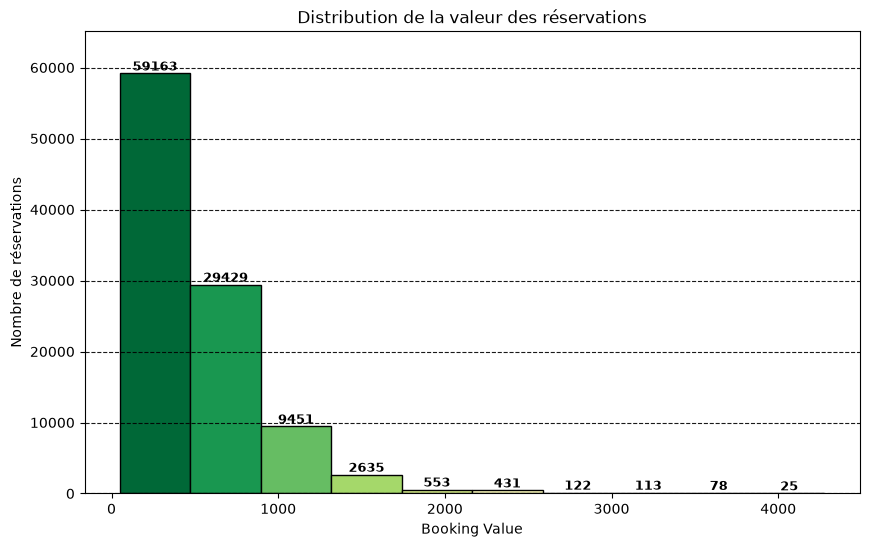

In [65]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Booking Value"].dropna(),
    bins=10,
    edgecolor="black"
)

# Normalisation des valeurs des classes
norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
cmap = plt.colormaps["RdYlGn_r"]  # Vert → Jaune → Rouge

# Attribution des couleurs
for i, patch in enumerate(patches):
    patch.set_facecolor(cmap(norm(bins[i])))

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # N'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.title("Distribution de la valeur des réservations")
plt.xlabel("Booking Value")
plt.ylabel("Nombre de réservations")
plt.grid(axis="y", linestyle="--", alpha=0.9, color="black")

# Laisse un peu d'espace au-dessus des barres pour les étiquettes
plt.ylim(0, max(n) * 1.1)

plt.show()

# Distribution de la distance en fonction du nombre de courses #

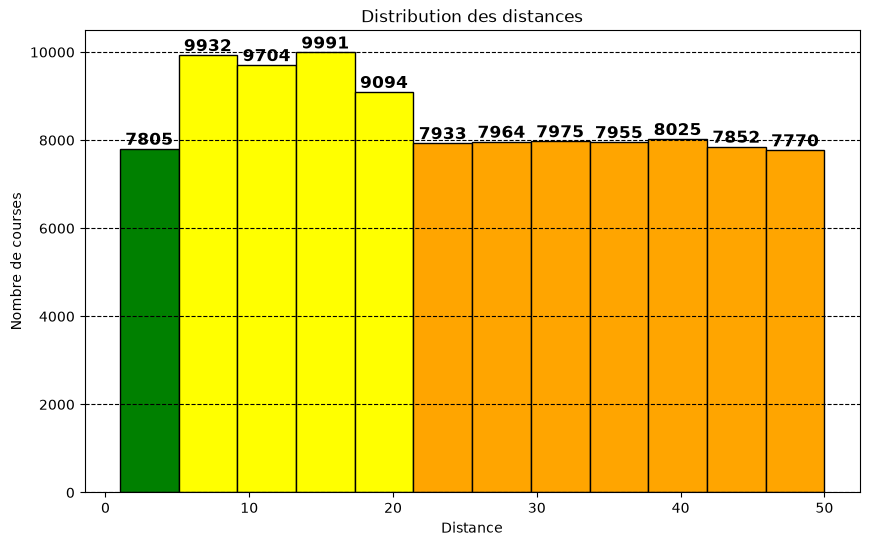

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Ride Distance"].dropna(),
    bins=12,
    edgecolor="black"

)

# Coloration selon la distance
for i, patch in enumerate(patches):
    if bins[i] < 5:
        patch.set_facecolor("green")
    elif bins[i] < 20:
        patch.set_facecolor("yellow")
    elif bins[i] < 50:
        patch.set_facecolor("orange")
    else:
        patch.set_facecolor("red")

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # n'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight= "bold"
            
        )

        

plt.title("Distribution des distances")
plt.xlabel("Distance")
plt.ylabel("Nombre de courses")
plt.grid(axis="y", linestyle="--", alpha=1.0, color="black")

plt.show()

# Répartitions des réservations #

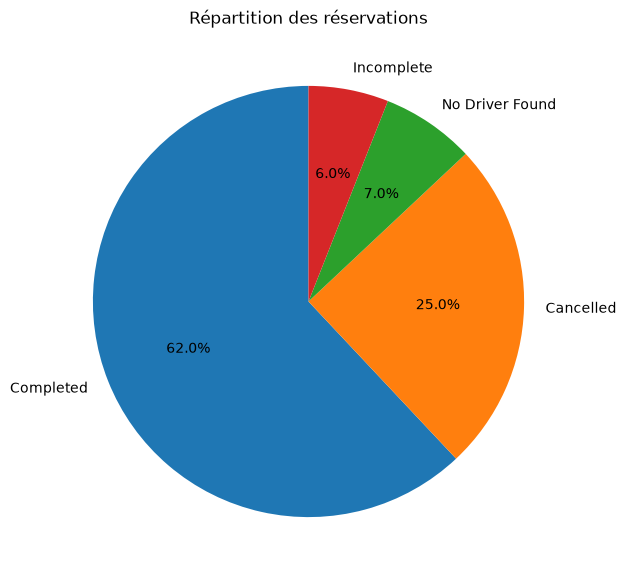

In [67]:
status = df["Booking Status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(status.values,
        labels=status.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Répartition des réservations")

plt.show()

# Top 15 des lieux où il y a eu le plus de commandes #

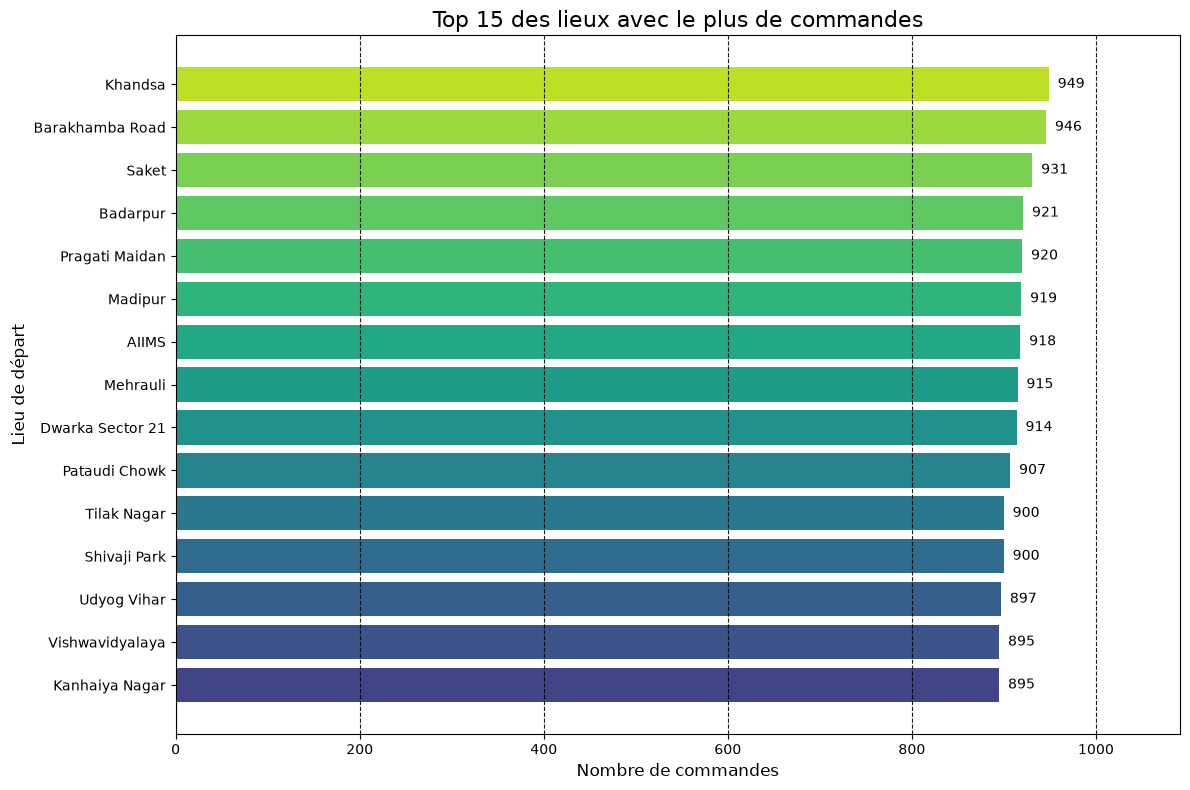

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Compter les commandes par lieu de départ
commandes_lieux = (
    df["Pickup Location"]
    .value_counts()
    .head(15)
    .sort_values()
)

# Création du graphique
plt.figure(figsize=(12, 8))

# Création des couleurs
couleurs = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(commandes_lieux))
)

plt.barh(
    commandes_lieux.index,
    commandes_lieux.values,
    color=couleurs
)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(commandes_lieux.values):
    plt.text(
        valeur + max(commandes_lieux.values)*0.01,
        i,
        f"{valeur}",
        va="center",
        fontsize=10
    )

# Ajouter une marge à droite
plt.xlim(
    0,
    max(commandes_lieux.values) * 1.15
)

plt.title(
    "Top 15 des lieux avec le plus de commandes",
    fontsize=16
)

plt.xlabel(
    "Nombre de commandes",
    fontsize=12
)

plt.ylabel(
    "Lieu de départ",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.9,
    color="black"
)

plt.tight_layout()
plt.show()

# Nombre de commandes selon l'heure de la journée #

C:\Users\yannb\AppData\Local\Temp\ipykernel_21676\2496649320.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(


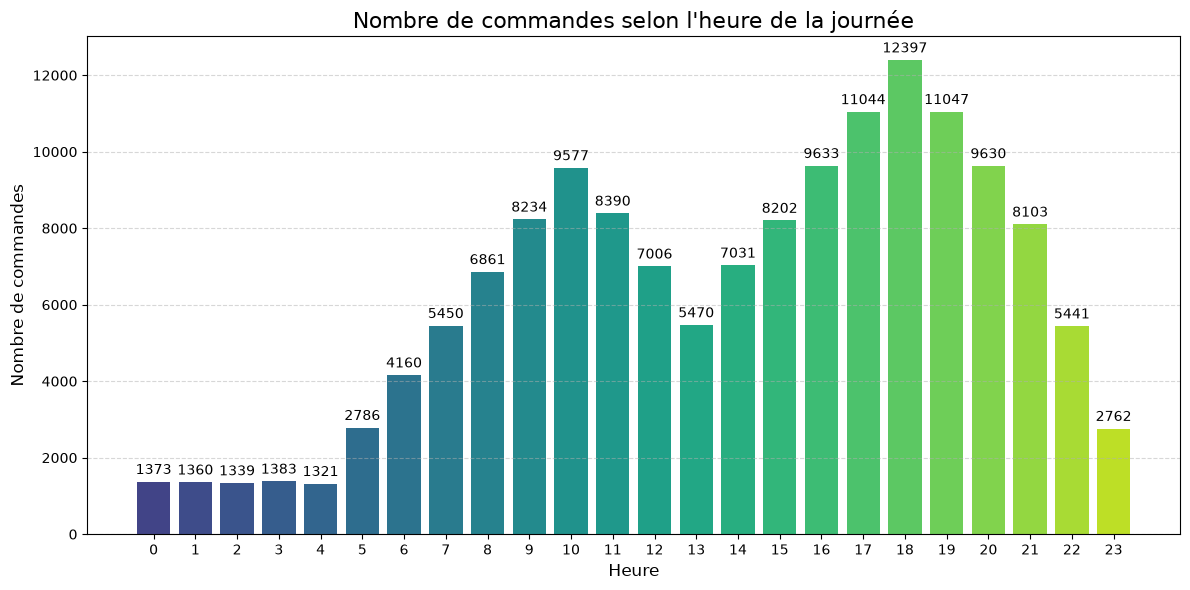

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Conversion de Time en datetime si nécessaire
df["Time"] = pd.to_datetime(
    df["Time"],
    errors="coerce"
)

# Extraire l'heure
df["Hour"] = df["Time"].dt.hour

# Compter les commandes par heure
commandes_heure = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

# Création du graphique
plt.figure(figsize=(12, 6))

# Couleurs en dégradé
couleurs = plt.cm.viridis(
    np.linspace(0.2, 0.9, len(commandes_heure))
)

plt.bar(
    commandes_heure.index,
    commandes_heure.values,
    color=couleurs
)

# Ajouter les valeurs au-dessus des barres
for heure, valeur in zip(
    commandes_heure.index,
    commandes_heure.values
):
    plt.text(
        heure,
        valeur + 200,
        str(valeur),
        ha="center",
        fontsize=10
    )

plt.title(
    "Nombre de commandes selon l'heure de la journée",
    fontsize=16
)

plt.xlabel(
    "Heure",
    fontsize=12
)

plt.ylabel(
    "Nombre de commandes",
    fontsize=12
)

plt.xticks(
    range(24)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

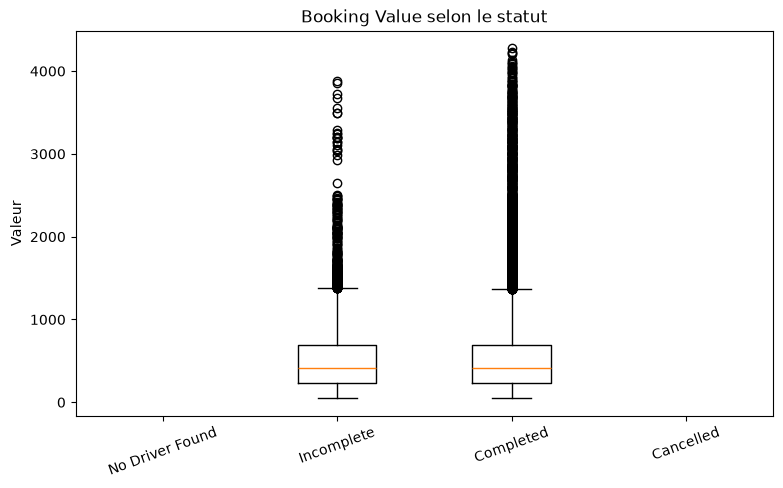

In [70]:
data = []
labels= []
for statut in df["Booking Status"].unique():
    data.append(
        df[df["Booking Status"] == statut]["Booking Value"].dropna()
    )

plt.figure(figsize=(9,5))

plt.boxplot(data,
            tick_labels=df["Booking Status"].unique())

plt.xticks(rotation=20)

plt.title("Booking Value selon le statut")

plt.ylabel("Valeur")

plt.show()

# Répartition des status des réservations #

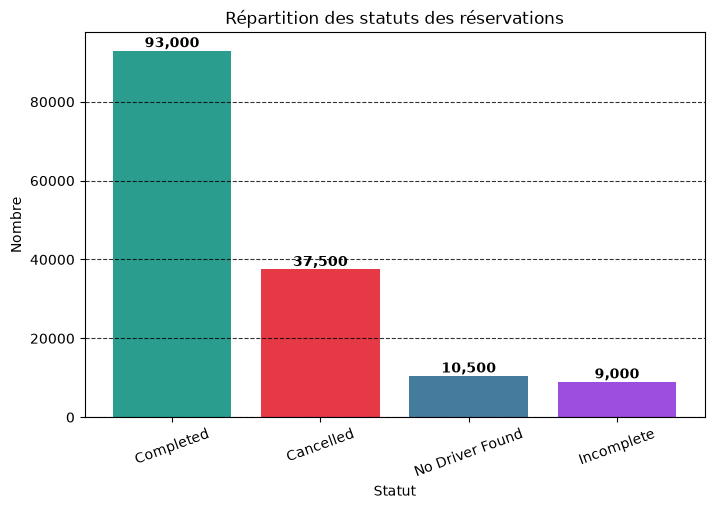

In [77]:
status = df["Booking Status"].value_counts()

couleurs = {
    "Completed": "#2A9D8F",
    "Cancelled": "#E63946",
    "No Driver Found": "#457B9D",
    "Incomplete": "#9D4EDD"
}

bar_colors = [couleurs[s] for s in status.index]

plt.figure(figsize=(8,5))

bars = plt.bar(status.index,
               status.values,
               color=bar_colors)

plt.title("Répartition des statuts des réservations")
plt.xlabel("Statut")
plt.ylabel("Nombre")

plt.xticks(rotation=20)

# Affichage des valeurs sur les barres
for bar in bars:
    hauteur = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        hauteur,
        f"{int(hauteur):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.8, color="black")

plt.show()

# Répartition des notes des chauffeurs #

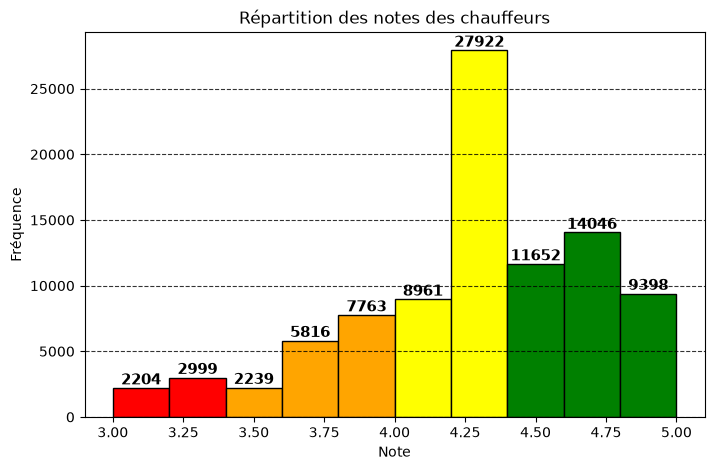

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Driver Ratings"].dropna(),
    bins=10,
    edgecolor="black"
)

# Couleur des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")      # Mauvaise note
    elif centre < 4.0:
        patches[i].set_facecolor("orange")   # Note moyenne
    elif centre < 4.5:
        patches[i].set_facecolor("yellow")   # Bonne note
    else:
        patches[i].set_facecolor("green")    # Excellente note

plt.title("Répartition des notes des chauffeurs")
plt.xlabel("Note")
plt.ylabel("Fréquence")

plt.grid(axis="y",
         linestyle="--",
         alpha=0.8,
         color="black")
for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

plt.show()

# Répartition des notes des clients #

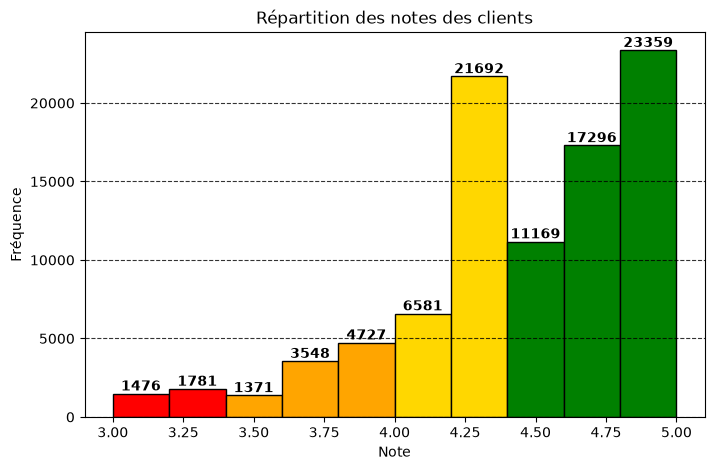

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

n, bins, patches = plt.hist(
    df["Customer Rating"].dropna(),
    bins=10,
    edgecolor="black"
)

# Coloration des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")
    elif centre < 4.0:
        patches[i].set_facecolor("orange")
    elif centre < 4.5:
        patches[i].set_facecolor("gold")
    else:
        patches[i].set_facecolor("green")

plt.title("Répartition des notes des clients")
plt.xlabel("Note")
plt.ylabel("Fréquence")
plt.grid(axis="y", linestyle="--", alpha=0.8, color ="black")

for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )
plt.show()

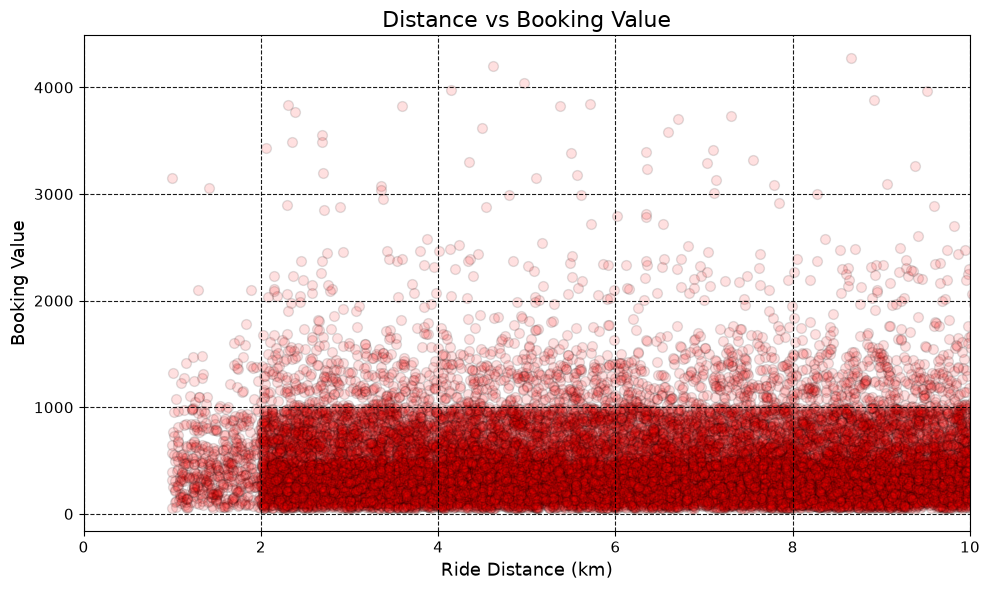

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.12,
    color="red",
    s=50,               # Taille des points
    edgecolors="black", # Contour des points
    linewidth=1
)

plt.title("Distance vs Booking Value", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=13)
plt.ylabel("Booking Value", fontsize=13)

# Taille des graduations
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher uniquement les distances entre 0 et 10
plt.xlim(0, 10)

plt.grid(True, linestyle="--", alpha=0.9, color= "black")

plt.tight_layout()
plt.show()

# Temps d'attente moyen pour l'arrivée d'un véhicule d'un conducteur #

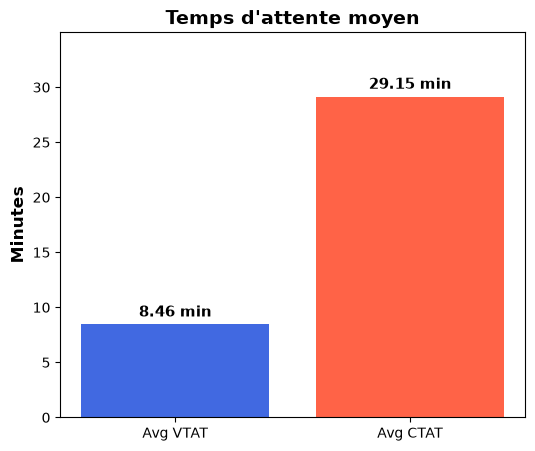

In [75]:
import matplotlib.pyplot as plt

moyennes = [
    df["Avg VTAT"].mean(),
    df["Avg CTAT"].mean()
]

labels = ["Avg VTAT", "Avg CTAT"]

plt.figure(figsize=(6,5))

bars = plt.bar(
    labels,
    moyennes,
    color=["royalblue", "tomato"]
)

# Affichage des valeurs au-dessus des barres
plt.bar_label(
    bars,
    fmt="%.2f min",      # 2 décimales + unité
    fontsize=11,
    fontweight="bold",
    padding=3
)

plt.ylabel("Minutes", fontsize=12, fontweight="bold")
plt.title("Temps d'attente moyen", fontsize=14, fontweight="bold")
plt.ylim(0, max(moyennes) * 1.2)

plt.show()

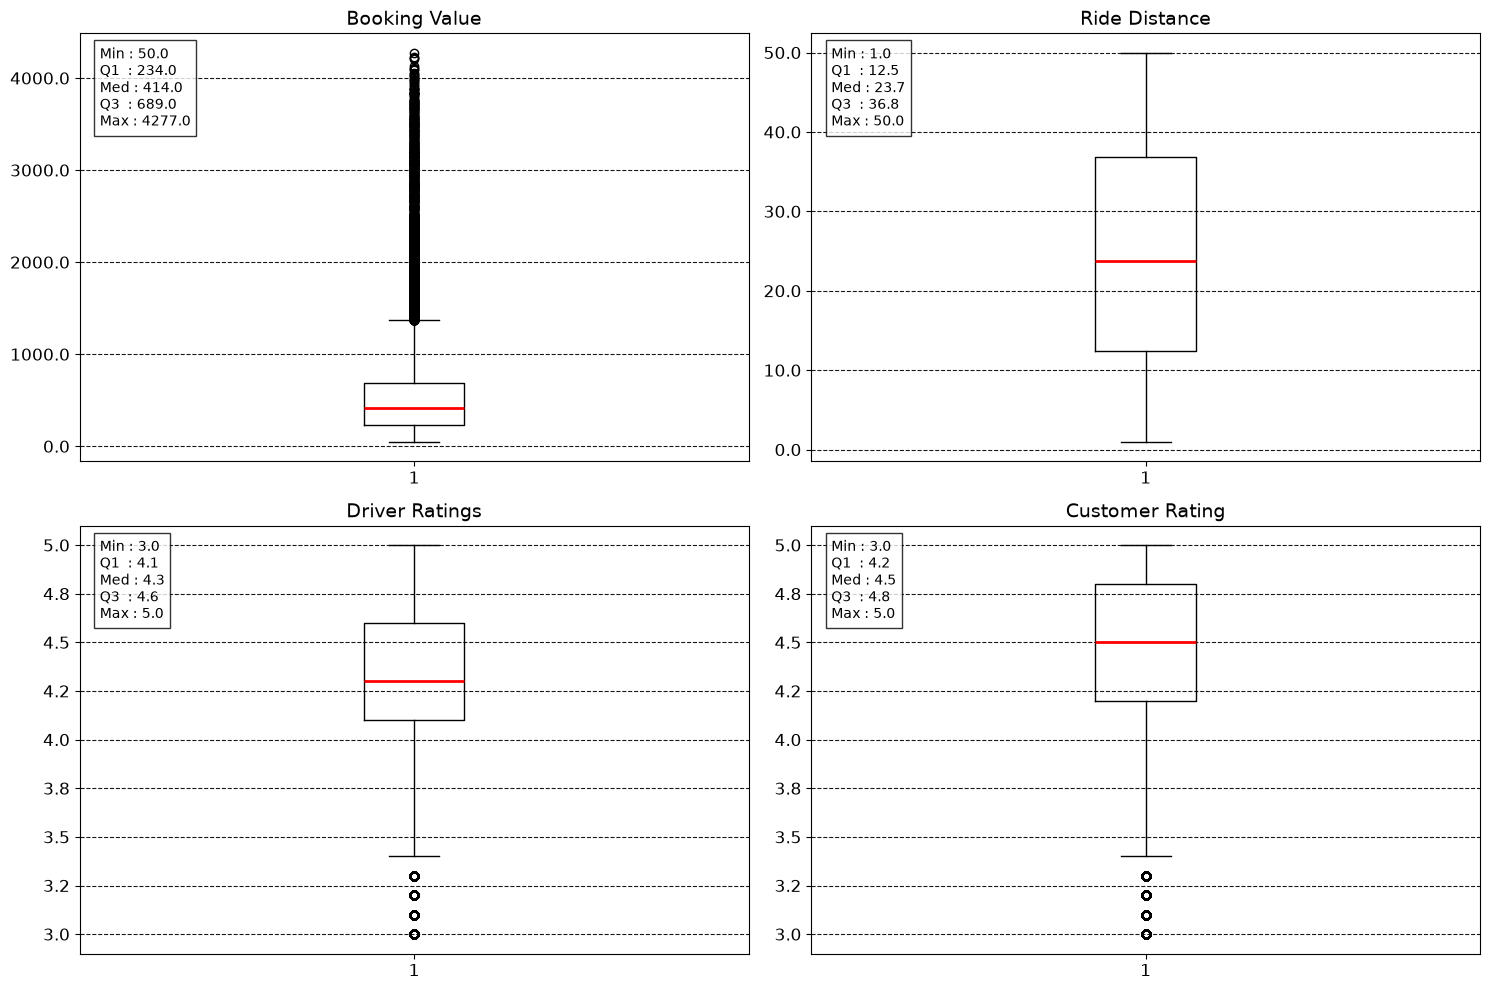

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

colonnes = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for axes, colonne in zip(ax.flat, colonnes):

    valeurs = df[colonne].dropna()

    axes.boxplot(
        valeurs,
        medianprops={
            "color": "red",
            "linewidth": 2
        }
    )

    axes.set_title(colonne, fontsize=14)
    axes.tick_params(labelsize=12)
    axes.grid(axis="y", linestyle="--", alpha=0.9, color="black")
    axes.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Calcul des statistiques
    mini = valeurs.min()
    q1 = valeurs.quantile(0.25)
    med = valeurs.median()
    q3 = valeurs.quantile(0.75)
    maxi = valeurs.max()

    # Texte des statistiques
    texte = (
        f"Min : {mini:.1f}\n"
        f"Q1  : {q1:.1f}\n"
        f"Med : {med:.1f}\n"
        f"Q3  : {q3:.1f}\n"
        f"Max : {maxi:.1f}"
    )

    # Affichage dans un encadré
    axes.text(
        0.03,
        0.97,
        texte,
        transform=axes.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox={
            "facecolor": "white",
            "edgecolor": "black",
            "alpha": 0.8
        }
    )

plt.tight_layout()
plt.show()